# Reading and plotting `python_scripts/` outputs

This notebook does **not** run any BEoRN physics - it imports
`artificial_halo_gpu.py` and `lpt_native_21cm.py` as plain Python modules
(for their `build_parameters()` / path / input-tag helpers) and reads the
grids each script already wrote to its `output/` directory, then reproduces
the same plots as `../artificial_halos.ipynb` and `../lpt_native_21cm.ipynb`.

**Run the scripts first:**
```bash
python artificial_halo_gpu.py
python lpt_native_21cm.py
```


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(0, str(Path.cwd()))
import beorn


---
## 1. Artificial halo run (`artificial_halo_gpu.py`)


In [2]:
import artificial_halo_gpu as ahg

parameters = ahg.build_parameters()
output_handler = beorn.io.Handler(ahg.OUTPUT_ROOT, input_tag=ahg.INPUT_TAG)
multi_z_quantities = output_handler.load_file(parameters, beorn.structs.TemporalCube)

print(f"Loaded {multi_z_quantities.z.size} snapshots, "
      f"z = {multi_z_quantities.z.min():.2f}-{multi_z_quantities.z.max():.2f}")


INFO:beorn.io.handler:Using persistence directory at /nobackup/proj/disk/cosmic_reion_2026/personal/sgiri/myPackages/BEoRN/examples/python_scripts/output


INFO:beorn.structs.temporal_cube:Opened 38 snapshots from /nobackup/proj/disk/cosmic_reion_2026/personal/sgiri/myPackages/BEoRN/examples/python_scripts/output/igm_data_artificial_halo_gpu_2d3cad16 (grid data is lazy — slices load on demand).


Loaded 38 snapshots, z = 6.00-24.50


### Maps at a single redshift

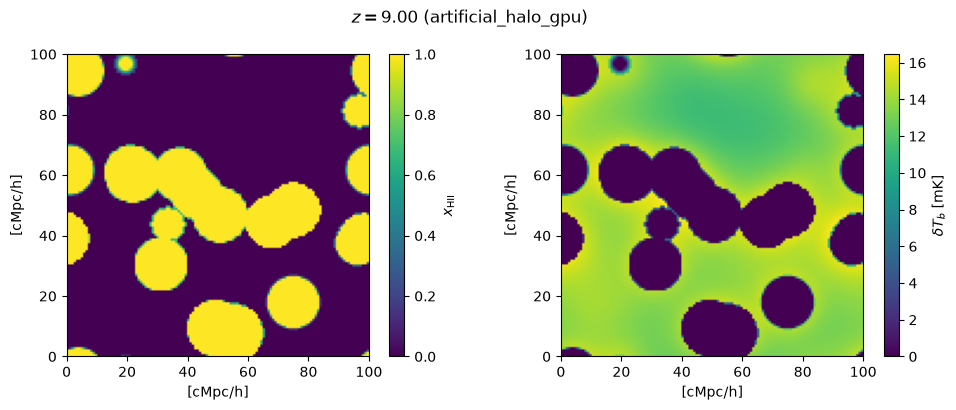

In [3]:
z_target = 9.0
Lbox = parameters.simulation.Lbox
extent = [0, Lbox, 0, Lbox]
mz_index = int(np.argmin(np.abs(multi_z_quantities.z - z_target)))
mid = parameters.simulation.Ncell // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, grid, label in zip(
    axes,
    [multi_z_quantities.Grid_xHII[mz_index, :, mid, :],
     multi_z_quantities.Grid_dTb[mz_index, :, mid, :]],
    [r'$x_\mathrm{HII}$', r'$\delta T_b$ [mK]'],
):
    im = ax.imshow(grid, origin='lower', cmap='viridis', extent=extent)
    ax.set_xlabel('[cMpc/h]')
    ax.set_ylabel('[cMpc/h]')
    fig.colorbar(im, ax=ax, label=label)

fig.suptitle(f'$z = {multi_z_quantities.z[mz_index]:.2f}$ (artificial_halo_gpu)')
plt.tight_layout()
plt.show()


### Global history and power spectra

Power spectrum:   0%|          | 0/38 [00:00<?, ?snapshot/s]

Power spectrum:   3%|▎         | 1/38 [00:00<00:04,  8.16snapshot/s]

Power spectrum:   5%|▌         | 2/38 [00:00<00:04,  8.65snapshot/s]

Power spectrum:   8%|▊         | 3/38 [00:00<00:04,  8.64snapshot/s]

Power spectrum:  11%|█         | 4/38 [00:00<00:03,  8.82snapshot/s]

...

Power spectrum:  95%|█████████▍| 36/38 [00:04<00:00,  8.46snapshot/s]

Power spectrum:  97%|█████████▋| 37/38 [00:04<00:00,  8.46snapshot/s]

Power spectrum: 100%|██████████| 38/38 [00:04<00:00,  8.46snapshot/s]

Power spectrum: 100%|██████████| 38/38 [00:04<00:00,  8.66snapshot/s]

k=0.12 Mpc$^{-1}$


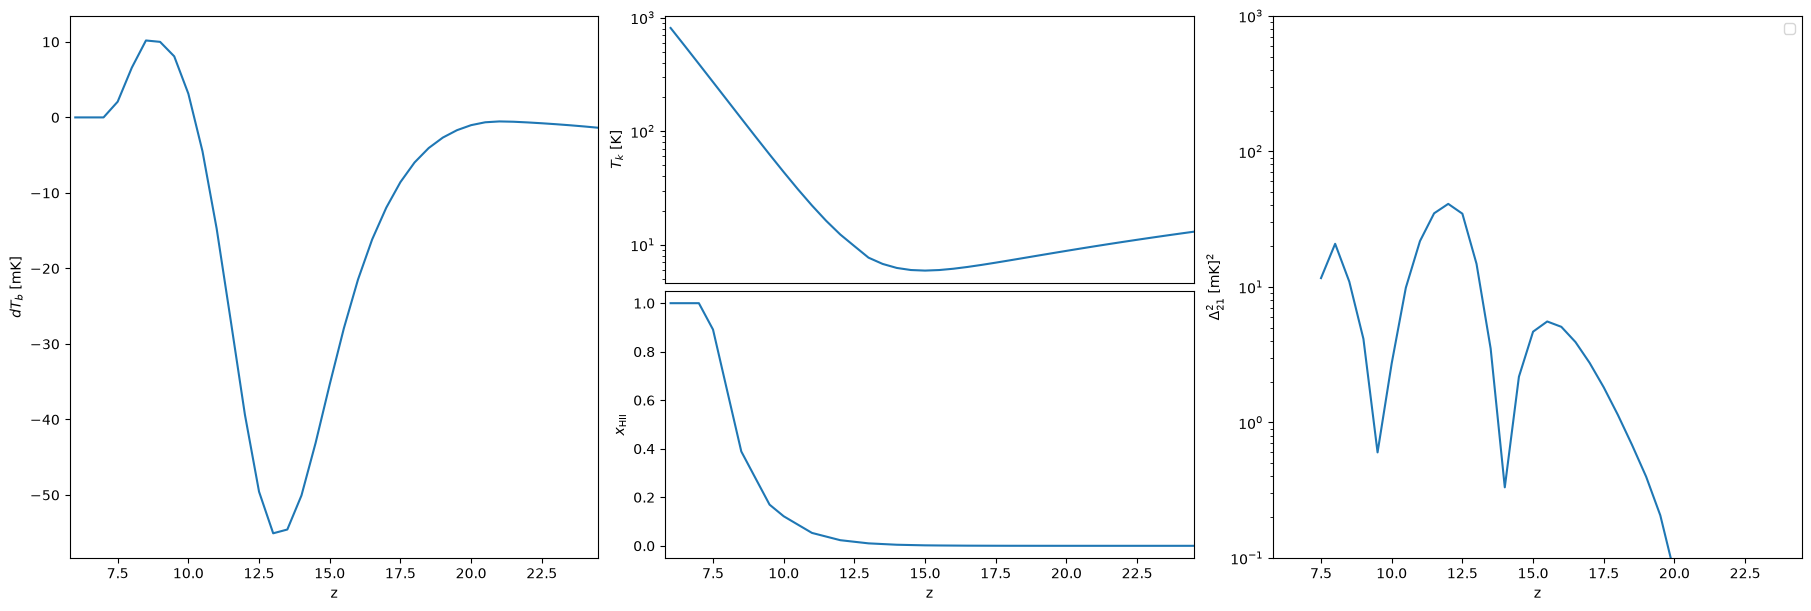

In [4]:
fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities)
beorn.plotting.draw_Temp_signal(ax2, multi_z_quantities)
beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities)
beorn.plotting.draw_dTb_power_spectrum_of_z(ax4, multi_z_quantities, parameters)

ax4.legend(loc='best')
ax2.axes.get_xaxis().set_visible(False)
plt.show()


### Summary statistics (`stats_*.h5`, saved by the script)

In [5]:
stats_path = ahg.OUTPUT_ROOT / f"stats_{ahg.INPUT_TAG}.h5"
stats = beorn.structs.StatisticsEstimator.from_file(stats_path)
print('Saved statistics:', list(stats.results.keys()))


Saved statistics: ['k', 'mean_Temp', 'mean_dTb', 'mean_xHII', 'mean_xal', 'ps_dTb', 'z']


### Lightcone

Making lightcone between 0.039216 < z < 0.142703


  0%|          | 0/547 [00:00<?, ?it/s]

 32%|███▏      | 174/547 [00:00<00:00, 1735.86it/s]

100%|██████████| 547/547 [00:00<00:00, 2816.77it/s]

...done


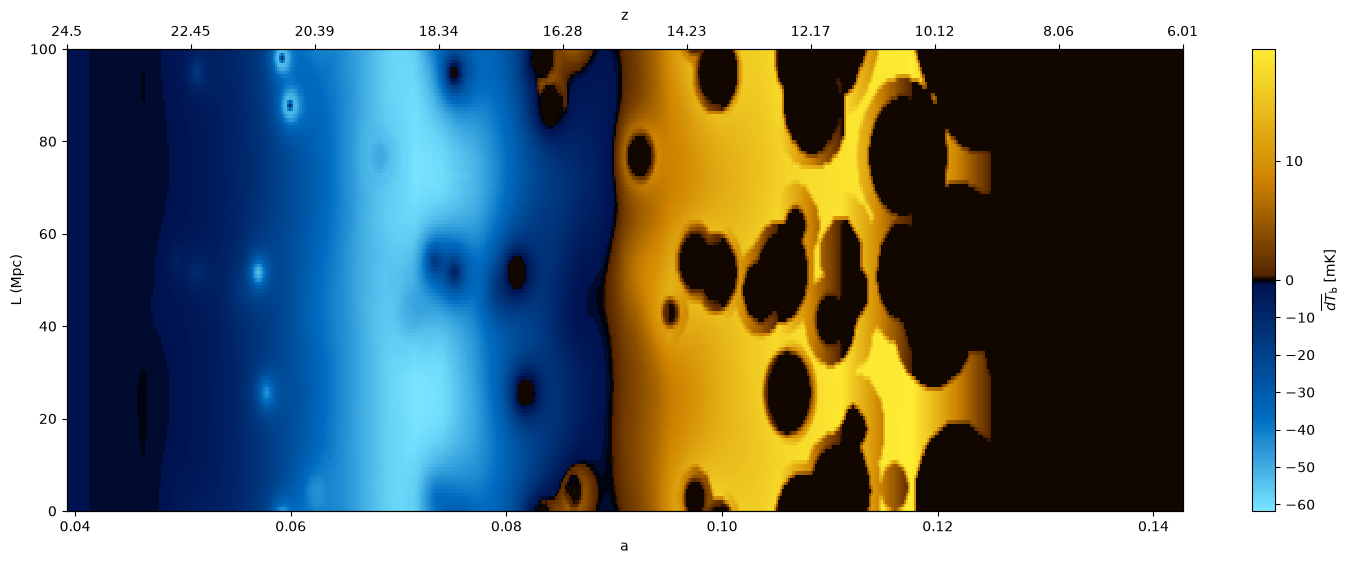

In [6]:
lightcone = beorn.structs.Lightcone.build(
    parameters,
    multi_z_quantities,
    quantity="Grid_dTb",
)

fig, ax = plt.subplots(figsize=(18, 6))
beorn.plotting.plot_lightcone(lightcone, ax, "", slice_number=mid)
plt.show()


---
## 2. Native LPT + CHMF run (`lpt_native_21cm.py`, driven by `param.yaml`)


In [7]:
import lpt_native_21cm as lnc

parameters2 = lnc.build_parameters()
seed2 = parameters2.cosmo_sim.IC_seed
input_tag2 = lnc.input_tag_for(parameters2, seed2)

output_handler2 = beorn.io.Handler(lnc.OUTPUT_ROOT, input_tag=input_tag2)
multi_z_quantities2 = output_handler2.load_file(parameters2, beorn.structs.TemporalCube)

print(f"Loaded {multi_z_quantities2.z.size} snapshots, "
      f"z = {multi_z_quantities2.z.min():.2f}-{multi_z_quantities2.z.max():.2f}")


INFO:beorn.io.handler:Using persistence directory at /nobackup/proj/disk/cosmic_reion_2026/personal/sgiri/myPackages/BEoRN/examples/python_scripts/output


INFO:beorn.structs.temporal_cube:Opened 30 snapshots from /nobackup/proj/disk/cosmic_reion_2026/personal/sgiri/myPackages/BEoRN/examples/python_scripts/output/igm_data_lpt_native_N128_L100_seed12345_ac6fabe3 (grid data is lazy — slices load on demand).


Loaded 30 snapshots, z = 5.50-20.00


### Maps at a single redshift

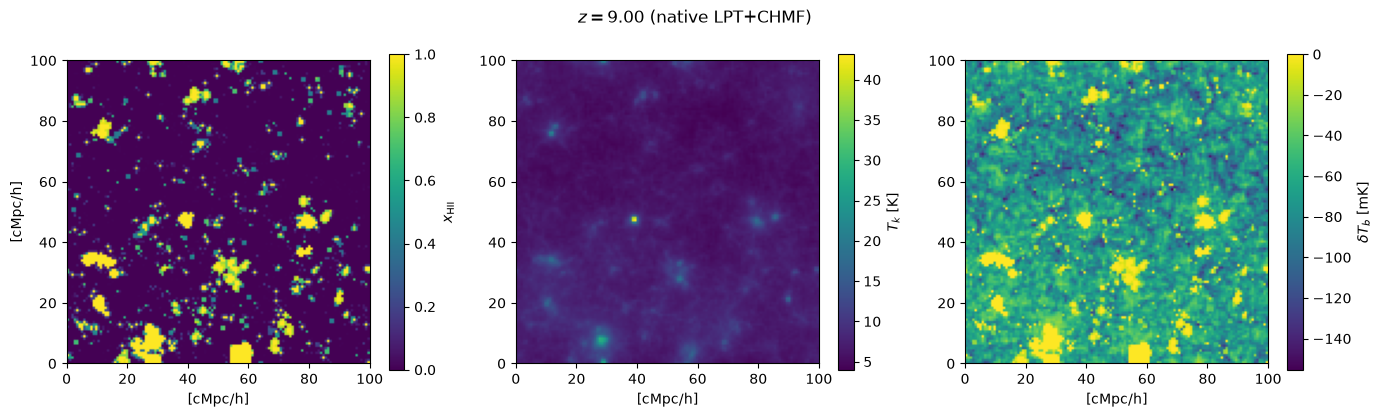

In [8]:
z_target2 = 9.0
Lbox2 = parameters2.simulation.Lbox
extent2 = [0, Lbox2, 0, Lbox2]
mz_index2 = int(np.argmin(np.abs(multi_z_quantities2.z - z_target2)))
mid2 = parameters2.simulation.Ncell // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, grid, label in zip(
    axes,
    [multi_z_quantities2.Grid_xHII[mz_index2, :, mid2, :],
     multi_z_quantities2.Grid_Temp[mz_index2, :, mid2, :],
     multi_z_quantities2.Grid_dTb[mz_index2, :, mid2, :]],
    [r'$x_\mathrm{HII}$', r'$T_k$ [K]', r'$\delta T_b$ [mK]'],
):
    im = ax.imshow(grid, origin='lower', cmap='viridis', extent=extent2)
    ax.set_xlabel('[cMpc/h]')
    fig.colorbar(im, ax=ax, label=label)
axes[0].set_ylabel('[cMpc/h]')
fig.suptitle(f'$z = {multi_z_quantities2.z[mz_index2]:.2f}$ (native LPT+CHMF)')
plt.tight_layout()
plt.show()


### Global history and power spectra

Power spectrum:   0%|          | 0/30 [00:00<?, ?snapshot/s]

Power spectrum:   3%|▎         | 1/30 [00:00<00:03,  8.80snapshot/s]

Power spectrum:   7%|▋         | 2/30 [00:00<00:03,  8.93snapshot/s]

Power spectrum:  10%|█         | 3/30 [00:00<00:03,  8.95snapshot/s]

Power spectrum:  13%|█▎        | 4/30 [00:00<00:02,  8.95snapshot/s]

...

Power spectrum:  93%|█████████▎| 28/30 [00:03<00:00,  8.91snapshot/s]

Power spectrum:  97%|█████████▋| 29/30 [00:03<00:00,  8.88snapshot/s]

Power spectrum: 100%|██████████| 30/30 [00:03<00:00,  8.93snapshot/s]

Power spectrum: 100%|██████████| 30/30 [00:03<00:00,  8.95snapshot/s]

k=0.12 Mpc$^{-1}$


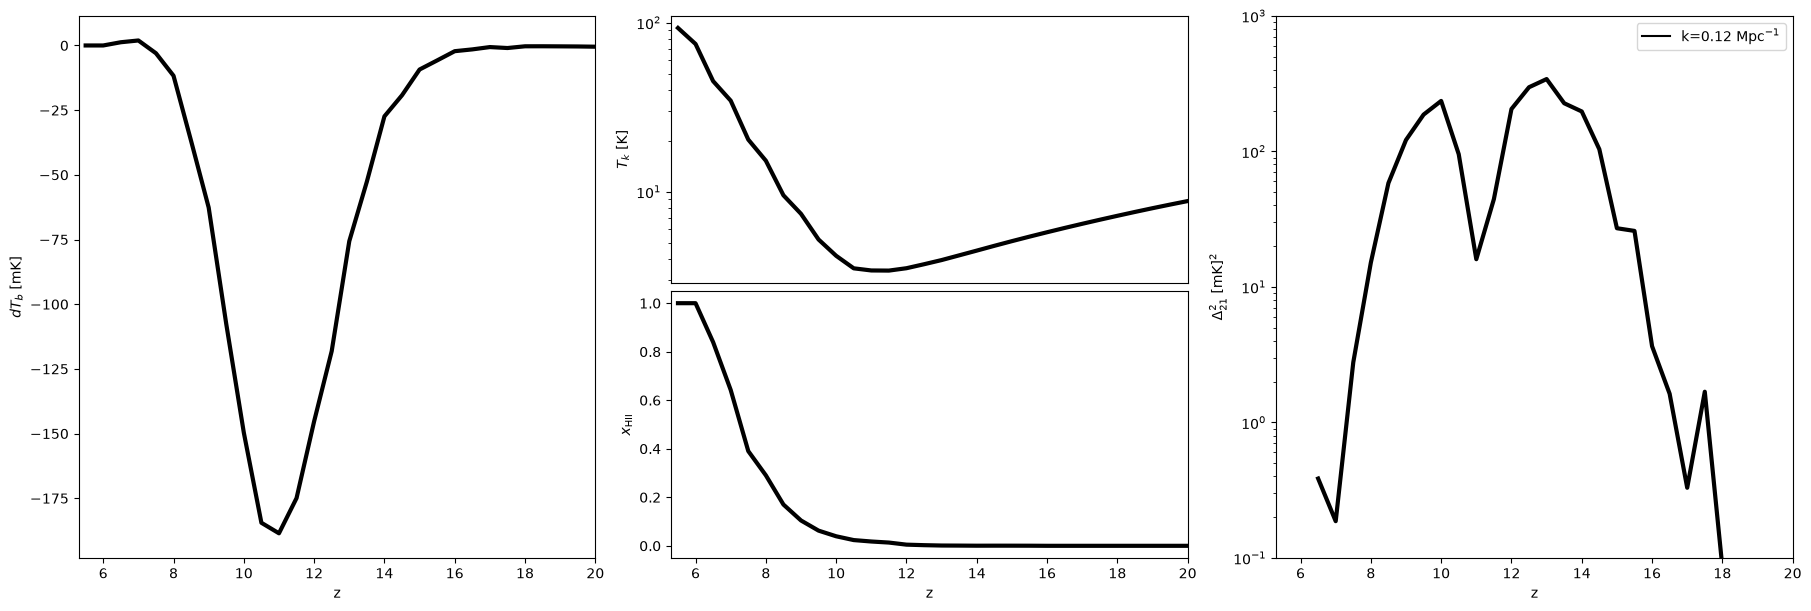

In [9]:
fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities2, color='k', lw=3)
beorn.plotting.draw_Temp_signal(ax2, multi_z_quantities2, color='k', lw=3)
beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities2, color='k', lw=3)
kplot = beorn.plotting.draw_dTb_power_spectrum_of_z(
    ax4, multi_z_quantities2, parameters2, k_value=0.1, color='k', lw=3)
ax4.plot([], [], color='k', label=f'k={kplot:.2f} Mpc$^{{-1}}$')
ax4.legend(loc=0)
ax2.axes.get_xaxis().set_visible(False)
plt.show()


### Lightcone

Making lightcone between 0.047619 < z < 0.153845


  0%|          | 0/559 [00:00<?, ?it/s]

 67%|██████▋   | 372/559 [00:00<00:00, 3676.81it/s]

100%|██████████| 559/559 [00:00<00:00, 4149.39it/s]

...done


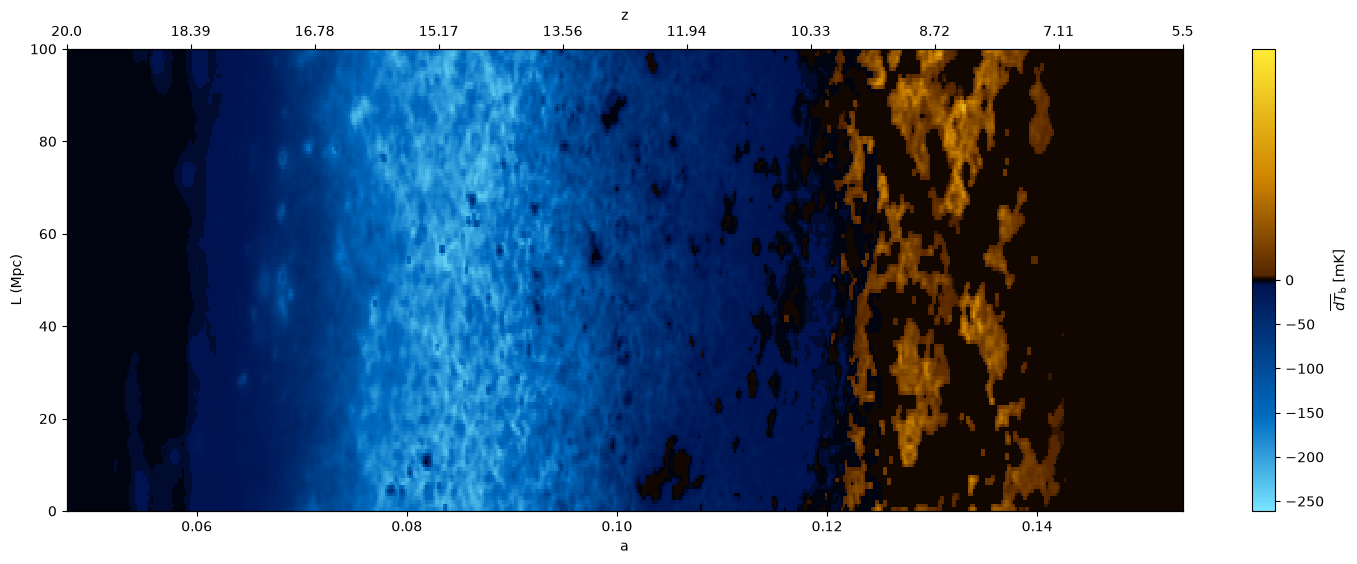

In [10]:
lightcone2 = beorn.structs.Lightcone.build(
    parameters2,
    multi_z_quantities2,
    quantity="Grid_dTb",
)

fig, ax = plt.subplots(figsize=(18, 6))
beorn.plotting.plot_lightcone(lightcone2, ax, "", slice_number=mid2)
plt.show()
